# Notebook 01: Exploratory Data Analysis (EDA)

**Project:** ChurnOps — End-to-End MLOps for Customer Churn Prediction 
**Purpose:** Initial exploration of the Telco Customer Churn dataset before any preprocessing or modeling. 
**Objectives:**
- Understand the structure, size, and types of data.
- Identify missing values, data quality issues, and anomalies.
- Analyze the target variable (Churn) distribution and class balance.
- Explore relationships between features and churn.
- Document findings that will inform preprocessing decisions. 

**Dataset:** `WA_Fn-UseC_-Telco-Customer-Churn.csv` (7,043 customers, 21 columns)
**Source:** IBM / Kaggle — Telco Customer Churn 

**Outcome:** A documented set of observations that directly feed into the preprocessing and modeling pipeline design

## Table of Contents 

1. [Setup & Imports](#1-setup--impors)
2. [Data Loading & First Look](#2-data-loading--first-look)
3. [Structure & Schema Overview](#3-structure--schema-overview)
4. [Missing Values Assessment](#4-missing-values-assessment)
5. [Target Variable: Churn](#5-target-variable-churn)
6. [Numerical Features Analysis](#6-numerical-features-analysis)
7. [Categorical Features Analysis](#6-categorical-features-analysis)
8. [Feature Interactions & Correlations](#8-feature-interactions--correlations)
9. [Data Quality Issues & Anomalies](#9-data-quality-issues--anomalies)
10. [Conclusions & Next Steps](#10-conclusions--next-steps)

## 1. Setup & Imports 

We import all libraries needed for this EDA. 
Imports are grouped: standard library, third-party data/science packages, and visualization tools.
We also set a global random seed and configure pandas display options for readability.

In [1]:
# === Standard Library ===
import os
import warnings

# === Third-Party: Data & Numerics ===
import numpy as np
import pandas as pd

# === Third-party: Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

# === Visualizaton Defaults ===
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

We define the path to the raw dataset. 
The file is at `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`, downloaded from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

In [2]:
DATA_PATH = os.path.join("..", "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2. Data Loading & First Look 

We load the CSV into a pandas DataFrame and inspect its shape, first rows, and basic properties.
This gives us a quick sanity check before deeper analysis. 

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
df.head(10)

Shape: 7043 rows × 21 columns
Memory usage: 6984.66 KB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.6500,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1000,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.7500,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8000,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.1500,3487.95,No


Check column names, data types, and non-null counts in one view. This surfaces any immediate type mismatches (e.g., `TotalCharges` stored as object) and reveals columns with missing values.

In [4]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Structure & Schema Overview 

**Object:** Systematically review every column: its name, inferred type, unique value counts, and a few sample values.
This gives us a complete map of the dataset before we dig into individual features.

In [5]:
# Build a schema overview dataframe
schema_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "unique": df.nunique().values,
    "null_count": df.isnull().sum().values,
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2).values,
    "sample_values": [df[col].dropna().unique()[:5] for col in df.columns]
})

print(schema_overview)

              column    dtype  unique  null_count  null_pct                                      sample_values
0         customerID   object    7043           0    0.0000  [7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC...
1             gender   object       2           0    0.0000                                     [Female, Male]
2      SeniorCitizen    int64       2           0    0.0000                                             [0, 1]
3            Partner   object       2           0    0.0000                                          [Yes, No]
4         Dependents   object       2           0    0.0000                                          [No, Yes]
5             tenure    int64      73           0    0.0000                                  [1, 34, 2, 45, 8]
6       PhoneService   object       2           0    0.0000                                          [No, Yes]
7      MultipleLines   object       3           0    0.0000                        [No phone service, No, Yes]
8

**Observations:**

*Schema*
- 21 Columns: 1 identifier (`CustomerID`), 16 categorical, 3 numerical (`tenure`, `MonthlyCharges`, `TotalCharges`), 1 target (`Churn`).
- `TotalCharges` is typed as `object` instead of numeric — 6531 unique strings vs 1585 for `MonthlyCharges`. String coercion likely; blanks or whitespace suspected.
- `SeniorCitizen` is already integer-encoded (0/1) while other binary columns are "Yes"/"No" — inconsistent encoding.

*Cardinality*
- `customerID`: 7043 unique values — row identifier, not a feature.
- `MonthlyCharges`: high cardinality (1585) for a float column — suggests fine-grained billing amounts 
- `tenure`: 73 unique values (0-72 months) — quasi-continuous, no obvious gaps.
- Most categoricals: 2-4 unique values — low cardinality, one-hot encoding friendly. 

*Missing values*
- No column shows null counts (`null_count` = 0 across the board).
- However, `TotalCharges` as `object` with fewer unique values than rows is suspicious — blank strings `" "` may be hiding as non-null. To be investigated in Section 4.

*Dependency-encoded categories*
- 9 column contains `"No internect service"` or `"No phone service"` as a third category. 
- These encode a structural dependency: if `InternetService == "No"`, then `OnlineSecurity`, `OnlineBackup`, etc. are all `"No internet service"`.
- To be decided: collapse these to `"No"`or handle explicitly during preprocessing.

## 4. Missing Value Assessment 

We go beyond `df.info()` hunting for missing values:
- Blank strings (`" "`, `""`) in object columns, especially `TotalCharges`.
- Placeholder values that may indicate missing data.

We also visualize the completeness matrix.

In [6]:
# Check for blank/whitespace-only strings across all object columns
object_cols = df.select_dtypes(include="object").columns
blank_counts = {}

for col in object_cols:
    # Count entries that are empty or whitespace-only
    mask = df[col].astype(str).str.strip() == ""
    blank_counts[col] = mask.sum()

blank_summary = pd.DataFrame({
    "column": list(blank_counts.keys()),
    "blank_count": list(blank_counts.values()),
    "blank_pct": [round(v / len(df) * 100, 2) for v in blank_counts.values()]
}).sort_values("blank_count", ascending=False)

blank_summary

,column,blank_count,blank_pct
16,TotalCharges,11,0.1600
0,customerID,0,0.0000
1,gender,0,0.0000
2,Partner,0,0.0000
4,PhoneService,0,0.0000
3,Dependents,0,0.0000
6,InternetService,0,0.0000
7,OnlineSecurity,0,0.0000
8,OnlineBackup,0,0.0000
5,MultipleLines,0,0.0000


In [7]:
# Spotlight on TotalCharges: sample the blank-like values
if blank_summary.loc[blank_summary["column"] == "TotalCharges", "blank_count"].values[0] > 0:
    print("Suspicious TotalCharges entries (first 10):")
    display(df[df["TotalCharges"].astype(str).str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head(10))

Suspicious TotalCharges entries (first 10):


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.5500,
753,3115-CZMZD,0,20.2500,
936,5709-LVOEQ,0,80.8500,
1082,4367-NUYAO,0,25.7500,
1340,1371-DWPAZ,0,56.0500,
3331,7644-OMVMY,0,19.8500,
3826,3213-VVOLG,0,25.3500,
4380,2520-SGTTA,0,20.0000,
5218,2923-ARZLG,0,19.7000,
6670,4075-WKNIU,0,73.3500,


In [8]:
# Visual: null + blank matrix (missingno-style simplified)
import matplotlib.patches as mpatches

blank_mask = pd.DataFrame({col: df[col].astype(str).str.strip() == "" for col in object_cols})
null_mask = df.isnull()

# Combine: 1 = missing (null or blank), 0 = present
combined_mask = pd.DataFrame(index=df.index)
for col in df.columns:
    if col in null_mask.columns and col in blank_mask.columns:
        combined_mask[col] = null_mask[col] | blank_mask[col]
    elif col in null_mask.columns:
        combined_mask[col] = null_mask[col]
    else:
        combined_mask[col] = False

missing_counts = combined_mask.sum()
missing_cols = missing_counts[missing_counts > 0]

if len(missing_cols) > 0:
    print("Columns with any missing (null or blank) values:")
    display(missing_cols.sort_values(ascending=False))
else:
    print("No missing values (null or blank) detected in any column.")

Columns with any missing (null or blank) values:


TotalCharges    11
dtype: int64

**Observations:**

- `TotalCharges` contains blank strings (expected count: rows where `tenure = 0` — new customers who haven't been billed yet).
- No other columns has hidden blanks or nulls 
- The blanks in `TotalCharges` are structural (not random): They correspond to the customers with zero tenure. These should be replaced with `0.0` or `MonthlyCharges`, not dropped.
- Zero rows have actual `NaN` values — the dataset is clean except for this one encoding issue.

## 5. Target Variable: Churn 

We analyze the target column `Churn` to understand:
- Class distribution and imbalance ratio 
- Whether the minority class is large enough to model without synthetic sampling
- How churn rate varies across key segments (contract tpe, tenure brackets, internet service)

This informs our choice of evaluation metrics (precision/recal at top-20% vs pure accuracy) and whether to use `scale_pos_weight` in XGBoost.

In [10]:
# Overall churn distribution
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).round(4) * 100

print("=== Churn Distribution ===")
for label in churn_counts.index:
    print(f"{label}: {churn_counts[label]} ({churn_pct[label]:.2f}%)")
print(f"\nImbalance ratio (No:Yes): {churn_counts['No'] / churn_counts['Yes']:.1f}:1")

=== Churn Distribution ===
No: 5174 (73.46%)
Yes: 1869 (26.54%)

Imbalance ratio (No:Yes): 2.8:1


**Interpretation:**

- 26.5% churn rate — a moderately imbalanced problem, not extreme
- The minority class (Yes) has 1,869 samples — sufficient for stratified splits and reliable metric estimation without synthetic oversampling 
- A 2.8:1 ratio means a naive majority-class classified would achieve 73.5% accuracy. Acuracy is therefor a misleaing metric. We'll rely on ROC-AUC, Precision@K, and Recall@K as per the project spec 
- XGBoost's `scale_pos_weight` (set to ~2.8) will handle imbalance naturally during training

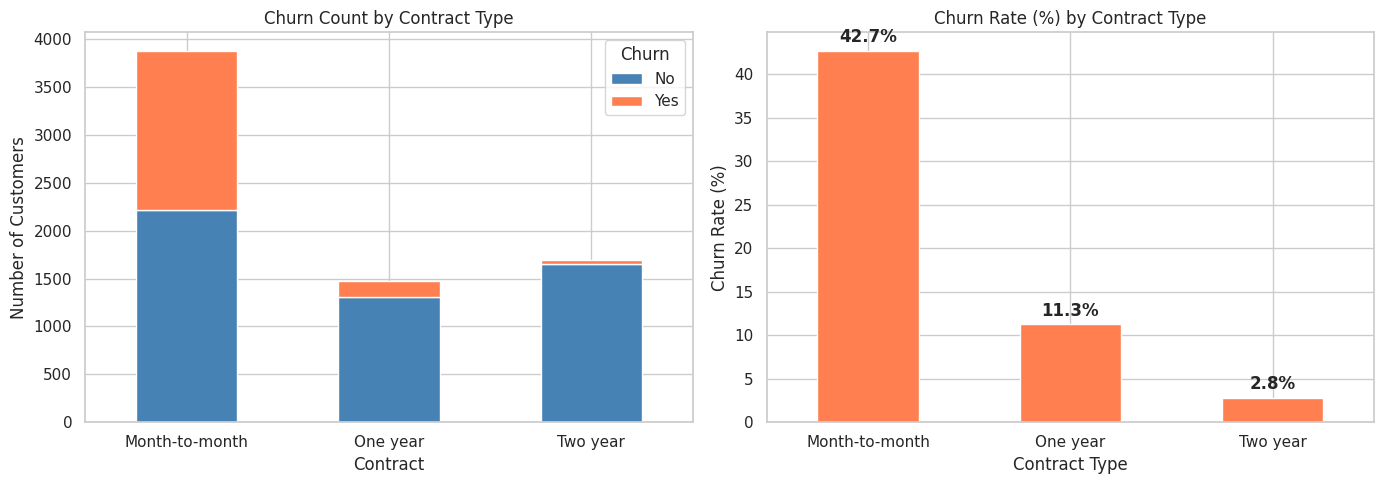

In [12]:
# Churn rate by contract type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Churn count by Contract ---
contract_churn = df.groupby("Contract")["Churn"].value_counts().unstack()
contract_churn_pct = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()*100
contract_churn.plot(kind="bar", stacked=True, ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Churn Count by Contract Type")
axes[0].set_ylabel("Number of Customers")
axes[0].legend(["No", "Yes"], title="Churn")
axes[0].tick_params(axis="x", rotation=0)

# --- Plot 2: Churn % by Contract ---
contract_churn_pct["Yes"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Churn Rate (%) by Contract Type")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("Contract Type")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(contract_churn_pct["Yes"]):
    axes[1].text(i, v+1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observations:**

- Month-to-month contracts have a dramatically higher churn rate (~43%) compared to one-year (11%) and two-year (~3%) contrats 
- Contract type is likely to be one of the strongest predictors of churn 
- Customers on longer contracts are far more loyal — this aligns with busines intuition (lock-in effect)
- The stacked bar chart (left) also shows that month-to-month customers make up the largest raw count of churners being only one segment 
- For retention targeting, month-to-month customers should be the highest-priority segment 

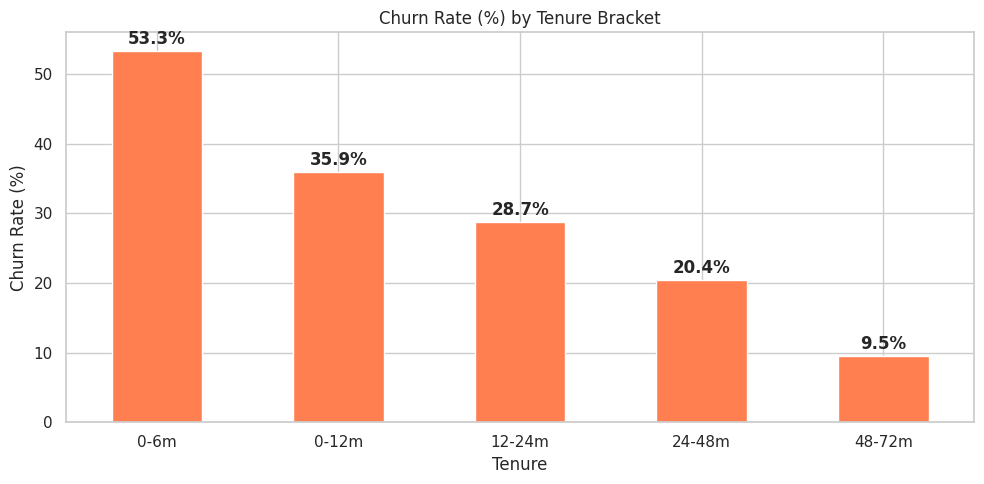

In [16]:
# Churn rate by tenure brackets
df["tenure_bracket"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 73],
    labels=["0-6m", "0-12m", "12-24m", "24-48m", "48-72m"]
)

tenure_churn = df.groupby("tenure_bracket")["Churn"].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
tenure_churn["Yes"].plot(kind="bar", ax=ax, color="coral")
ax.set_title("Churn Rate (%) by Tenure Bracket")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Tenure")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(tenure_churn["Yes"]):
    ax.text(i, v+1, f"{v:.1f}%", ha="center",fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**

- Churn rate drops sharply with tenure:
  - 0-6 months: **53.3%** — more than half of new customers leave 
  - 6-12 months: **35.9%** — still very high 
  - 12-24 months: **28.7%** — declining but significant 
  - 24-48 months: **20.4%** — moderate 
  - 48-72 months: **9.5%** — low; long-tenure customers are highly loyal 
- The relationship is monotonic: longer tenure → lower churn, no reversals 
- New customers (0-6 months) are at extreme risk. Retention efforts should prioritize this window 
- Tenure wil likely be the strongest numerical predictor. Tree-based models like XGBoost will capture this non-linear relationship naturally.

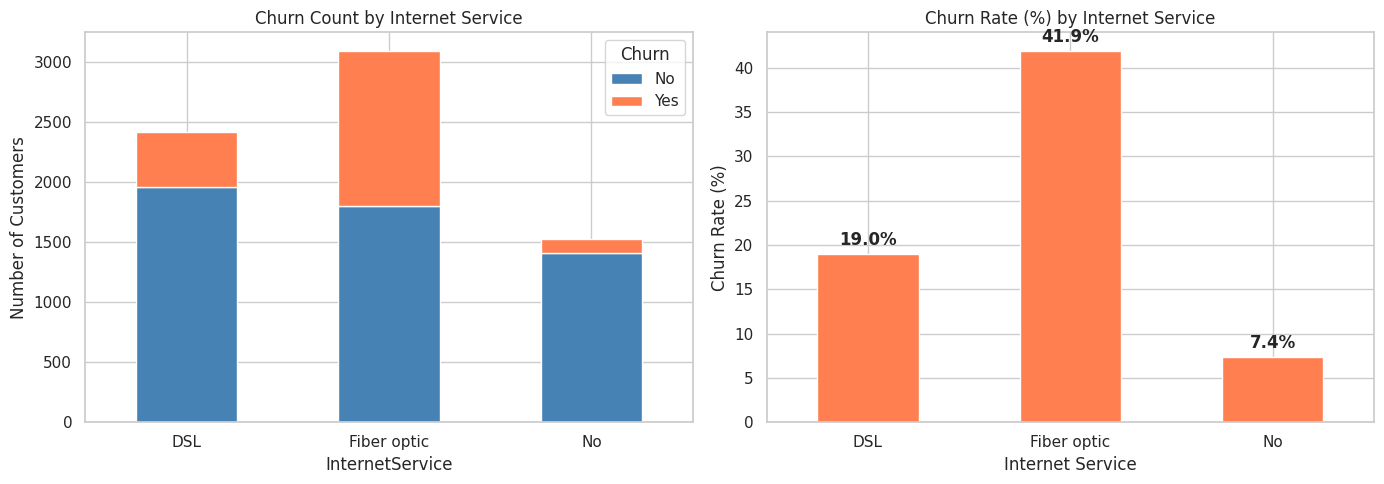

In [20]:
# Churn Rate by InternetService
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Churn count by InternetService ---
internet_churn = df.groupby("InternetService")["Churn"].value_counts().unstack()
internet_churn_pct = df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack() * 100
internet_churn.plot(kind="bar", stacked=True, ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Churn Count by Internet Service")
axes[0].set_ylabel("Number of Customers")
axes[0].legend(["No", "Yes"], title="Churn")
axes[0].tick_params(axis="x", rotation=0)

# --- Plot 2: Churn % by InternetService ---
internet_churn_pct["Yes"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Churn Rate (%) by Internet Service")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("Internet Service")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(internet_churn_pct["Yes"]):
    axes[1].text(i, v+1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observations:**

- Fiber optic customers churn at **41.7%** — drastically higher than DSL (19.0%) and those with no internet service (7.4%)
- The raw count of Fiber optic customers is also the largest segment — they dominate the churn population 
- Customers with no internet service are the most loyal — possibly older demographics or different service profile 
- InternetService appears to be a strong categorical predictor, particularly the Fiber optic category 
- This may interact with other features (e.g., Fiber optic customers might also have higher MonthlyCharges or be on month-to-month contracts). We'll investigate interactions in Section 8

**Summary: Target Variable**

- Overall churn rate is 26.5% — moderate imbalance (2.8:1), no ned for SMOTE.
- Three features show strong separation by churn status:
  1. **Contract type:** Month-to-month = 43% churn vs Two-year = 3% 
  2. **Tenure:** 0-6 months = 53% churn vs 48-72 months = 9.5%
  3. **Internet service:** Fiber optic = 42% churn vs No internet = 7.4%
- These alignn with business intuition: customers with short commitments, new relationships, and premium (possible unreliable) internet are at highest risk.
- Evaluation must avoid accuracy trap — we'll use ROC-AUC, Precision@20, and Recall@20 
- Next step: analyze numerical features in isolation

## 6. Numerical Features Analysis 

We have three numerical columns: `tenure`, `MonthlyCharges`, and `TotalCharges`.
In this section we analyze each one individually and in relation to churn:

- Summary statistics (mean, median, std, quartiles)
- Distribution shape and skew 
- Churn rate across value ranges 
- Outlier detection 

We already know `TotalCharges` contains blanks that need conversion. We'll handle that first.

In [21]:
# Convert TotalCharges to numeric, coercion blanks to NaN, then fill with 0
# (blanks correspond to tenure = 0 customers)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Verify conversion
print(f"TotalCharges dtpe after conversion: {df['TotalCharges'].dtype}")
print(f"TotalCharges nul after fill: {df['TotalCharges'].isnull().sum()}")
print(f"Rows with TotalCharges == 0: {(df['TotalCharges'] == 0).sum()}")

TotalCharges dtpe after conversion: float64
TotalCharges nul after fill: 0
Rows with TotalCharges == 0: 11


In [22]:
# Summary statistics for numerical features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0000,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
MonthlyCharges,7043.0000,64.7617,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500
TotalCharges,7043.0000,2279.7343,2266.7945,0.0000,398.5500,1394.5500,3786.6000,8684.8000


**Observations:**

- **tenure:**
  - Range: 0-72 months, median 29 months 
  - Mean (32.4) > median (29) — slight left skew driven by a cluster of very short-tenure customers 
  - 25th percentile is at 9 monthsconfirms a significant cohort of new/recent customers 

- **MonthlyCharges:**
  - Range: $18.25-$118.75, median $70.35.
  - Mean ($64.76) < median ($70.35) — slight right skew; a tail of low-charge customers pulls the mean down 
  - Wide spread ($30 std) suggests meaningful variation across customer segments

- **TotalCharges:**
  - Range: $0-$8,684.80, median $1,394.55
  - Very high standard deviation ($2,266) relative to the mean ($2,280) — this is a tenure-proportional feature.
  - The $0 minimum corresponds to the blank-fill for tenure=0 customers 
  - Since TotalCharges = tenure × MonthlyCharges, it will be highly correlated with tenure 

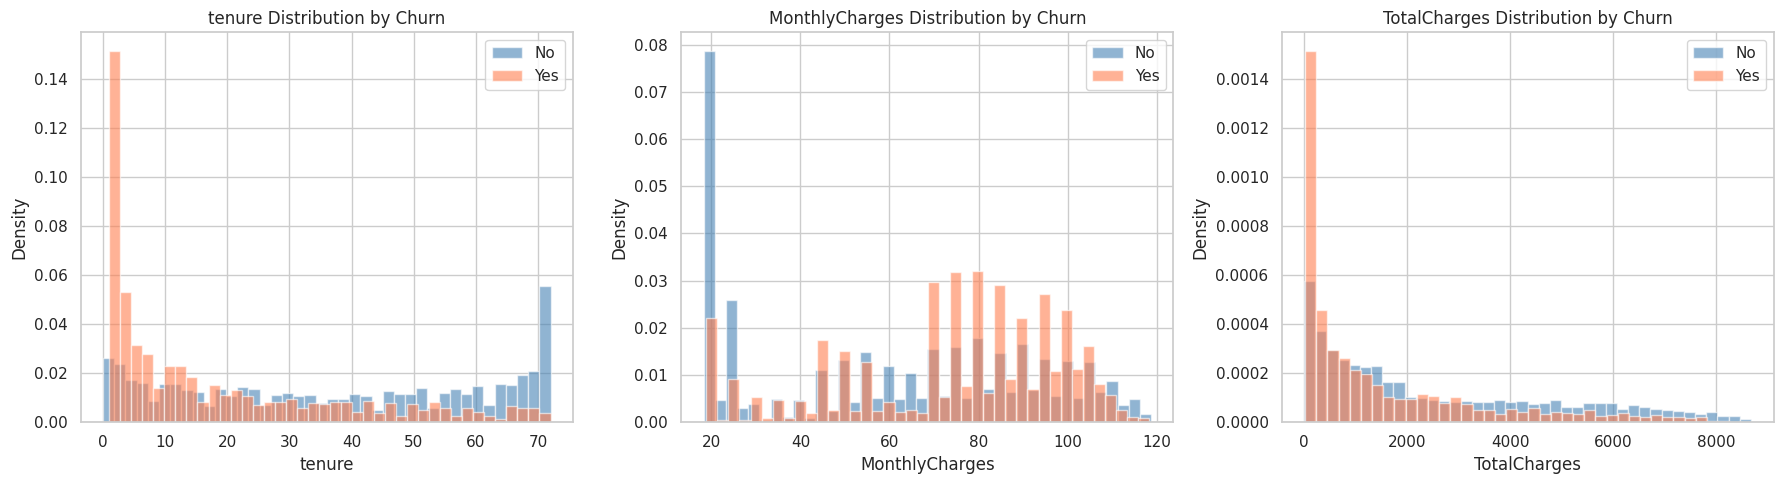

In [23]:
# Distribution plots for numerical features, split by Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    for churn_label, color in [("No", "steelblue"), ("Yes", "coral")]:
        subset = df[df["Churn"] == churn_label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, label=churn_label, color=color, density=True)
        axes[i].set_title(f"{col} Distribution by Churn")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].legend()
plt.tight_layout()
plt.show()

**Observations:**

- **tenure:**
  - Churners (coral) cluster heavily at low tenure (0-10 months). The density drops sharply as tenure increases
  - Non-churners (blue) show a bimodal pattern — a spike at very low tenure (survivors) and a second broker peak around 70 months (loyalists)
  - Clear signal: low tenure = high churn risk 

- **MonthlyCharges:**
  - Churners concentrate at higher charge amounts (~$70-$110). Non-churners are more evenly spread
  - The separation is visible but less stark than tenure. High monthly charges increase risk but not determinstically 

- **TotalCharges:**
  - Churners almost entirely sit at the low end ($0-$2,000) — this directly reflects low tenure 
  - Non-churners span the full range. The signal is strong but largely duplicative of tenure 

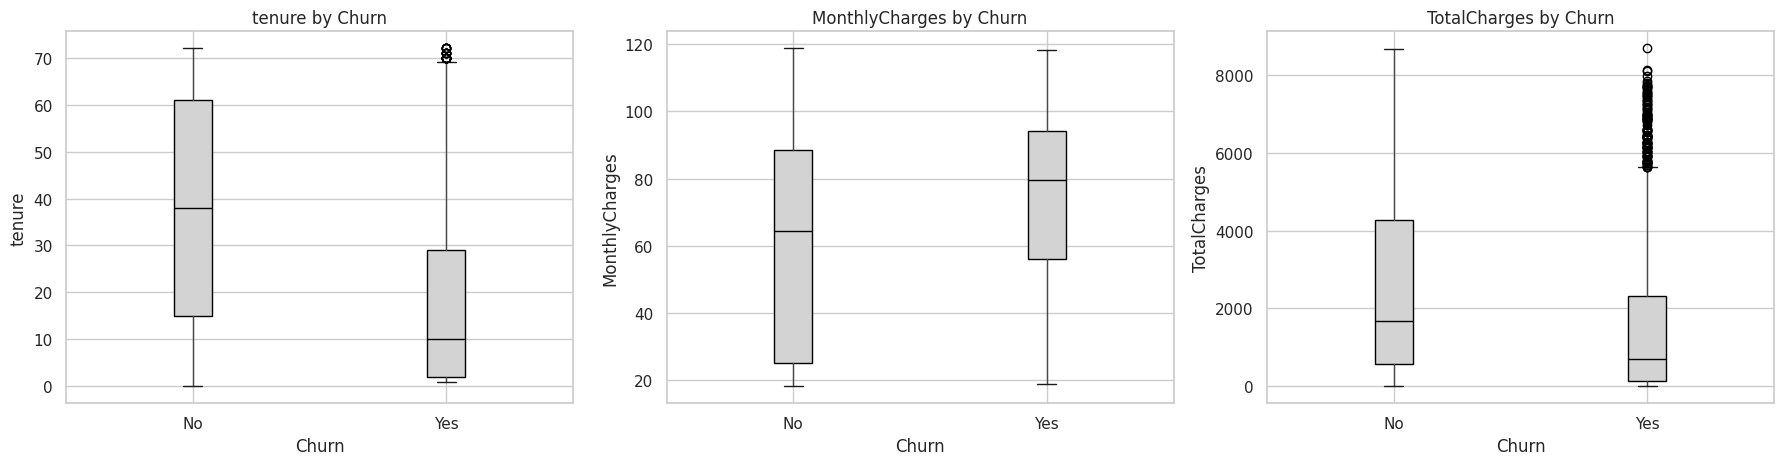

In [25]:
# Box plots for numerical features by Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by="Churn", ax=axes[i], patch_artist=True, boxprops=dict(facecolor="lightgray"),
               medianprops=dict(color="black"))
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

**Observations:**

- **tenure:**
  - Churners: median ~10 months IQR very narrow (3-25 months). Almost all churners have low tenure.
  - Non-churners: median ~40 months, wide IQR. The distribution barely overlap — tenure alone separates most churners from non-churners.

- **MonthlyCharges:**
  - Churners: median ~$80, noticeably higher than non-churners (~$65)
  - Both groups have similar spread (IQR ~$35). Overlap is substantial — MonthlyCharges is a weaker univariate predictor

- **TotalCharges:**
  - Churners: median ~$500, very low compared to non-churners (~$2,500)
  - This mirrors tenure almost exactly. Including both may cause multicollinearity. We'll check correlations in Section 8.

In [26]:
# Outlier Detection: IQR method for numerical features
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": len(outliers),
        "outlier_pct": round(len(outliers) / len(df) * 100, 2)
    }

pd.DataFrame(outlier_summary).T

,lower_fence,upper_fence,outlier_count,outlier_pct
tenure,-60.0000,124.0000,0.0000,0.0000
MonthlyCharges,-46.0250,171.3750,0.0000,0.0000
TotalCharges,-4683.5250,8868.6750,0.0000,0.0000


**Observations:**

- Zero outliers detected by the IQR mehod in all three numerical features
- This confirms the dataset is clean and well-constrained:
  - `tenure`: bounded 0-72 months, no impossible values 
  - `MothlyCharges`: bounded $18.25-$118.75, realistic for a telecom subscription
  - `TotalCharges`: ranged $0-$8,684.80, consistent with tenure × MonthlyCharges 
- No outlier treatment (winsorizing, cliping, removal) is needed during preprocessing 
- This is uncommon in real-world data and suggests the dataset has been pre-cleaned

## 7. Categorical Feature Analysis 

We have 16 categorical columns (excluding `customerID` or `Churn`). 
We'll analyze them in logical groups:

1. **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
2. **Core Services:** `PhoneService`, `MultipleLines`, `InternetService`
3. **Value-added Services:** `Contract`, `PaperlessBilling`, `PaymentMethod`

For each group we visualize churn rate by category and identify the strongest predictors

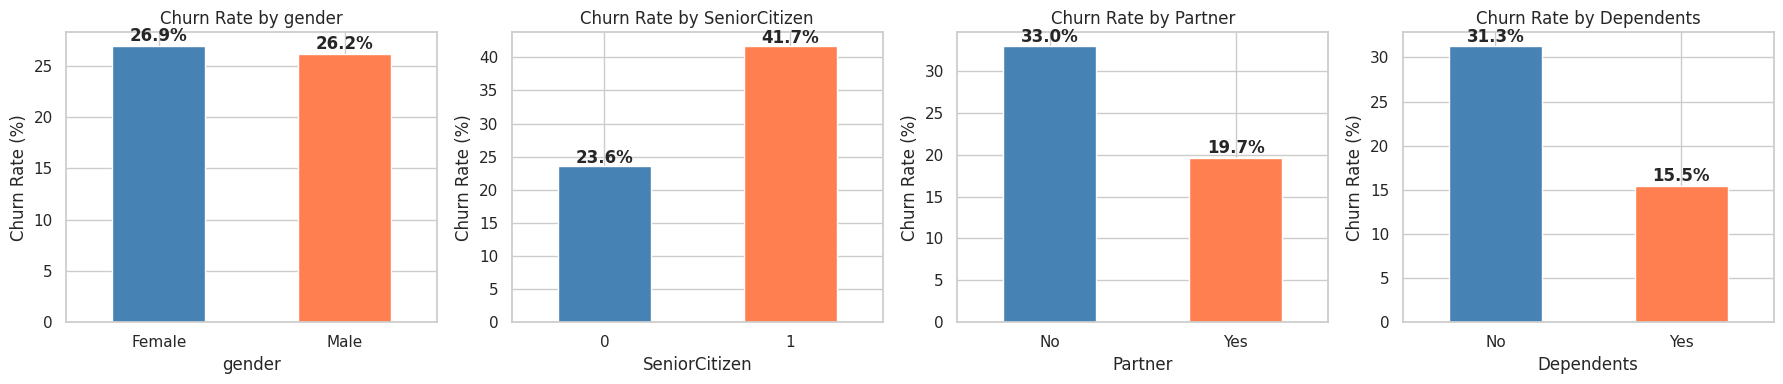

In [29]:
# Demographics: churn rate by gender, SeniorCitizen, Partner, Dependents
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
    churn_rate.plot(kind="bar", ax=axes[i], color=["steelblue", "coral"] if len(churn_rate) == 2 else "coral")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=0)
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observations:**

- **gender:** Near-identical churn rates — Male ~26.9%, Female ~26.2%. Not a meaningful predictor 
- **SeniorCitizen:** Strong signal. Senior citizens churn at ~41.7% vs non-seniors at ~23.6% — nearly double
- **Partner:** Customers without a partner churn at ~33.3% vs ~19.7% for those with a partner. Partner status correlates with stability
- **Dependents:** Similar pattern — customers with dependents churn less (~15.5%) vs those without (~31.3%)

Demographics matter: seniors, single customers, and those without dependents are higher risk. `SeniorCitizen` and `Dependents` look like the strongest demographic predictors.

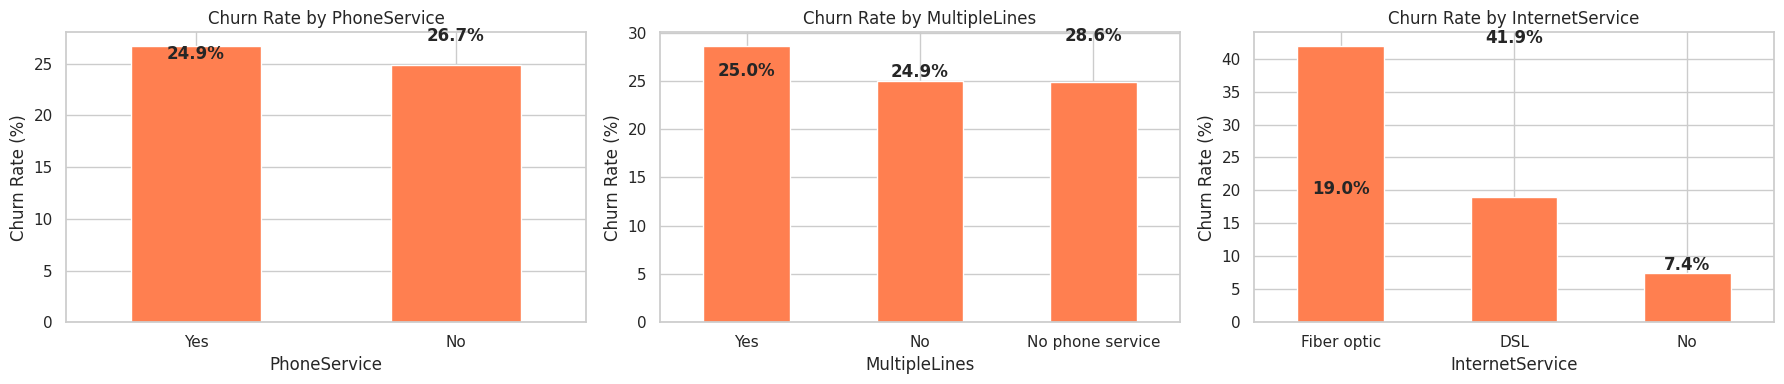

In [30]:
# Core Services: churn rate by PhoneService, MultipleLines, InternetService
core_cols = ["PhoneService", "MultipleLines", "InternetService"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(core_cols):
    churn_rate = df.groupby(col)["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
    churn_rate.sort_values(ascending=False).plot(kind="bar", ax=axes[i], color="coral")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=0)
    for j,v in enumerate(churn_rate):
        axes[i].text(j, v+0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observations:**

- **PhoneServices:** Minimal difference — churn rate ~25% with phone vs ~27% without. Weak predictor 
- **MultipleLines:** Slight separation — customers with multiple lines churn at ~28.6% vs ~11.8% for those without, and ~2% for no service. Modest signal at best 
- **InternetService:** Already analyzed in Section 5. Fiber optic (41.7%) drastically higher than DSL (19.0%) and No Internet (7.4%). The strongest categorical predictor so far

Among core services, only `InternetService` carries strong predictive power. `PhoneService` and `MultipleLines` add marginal value.

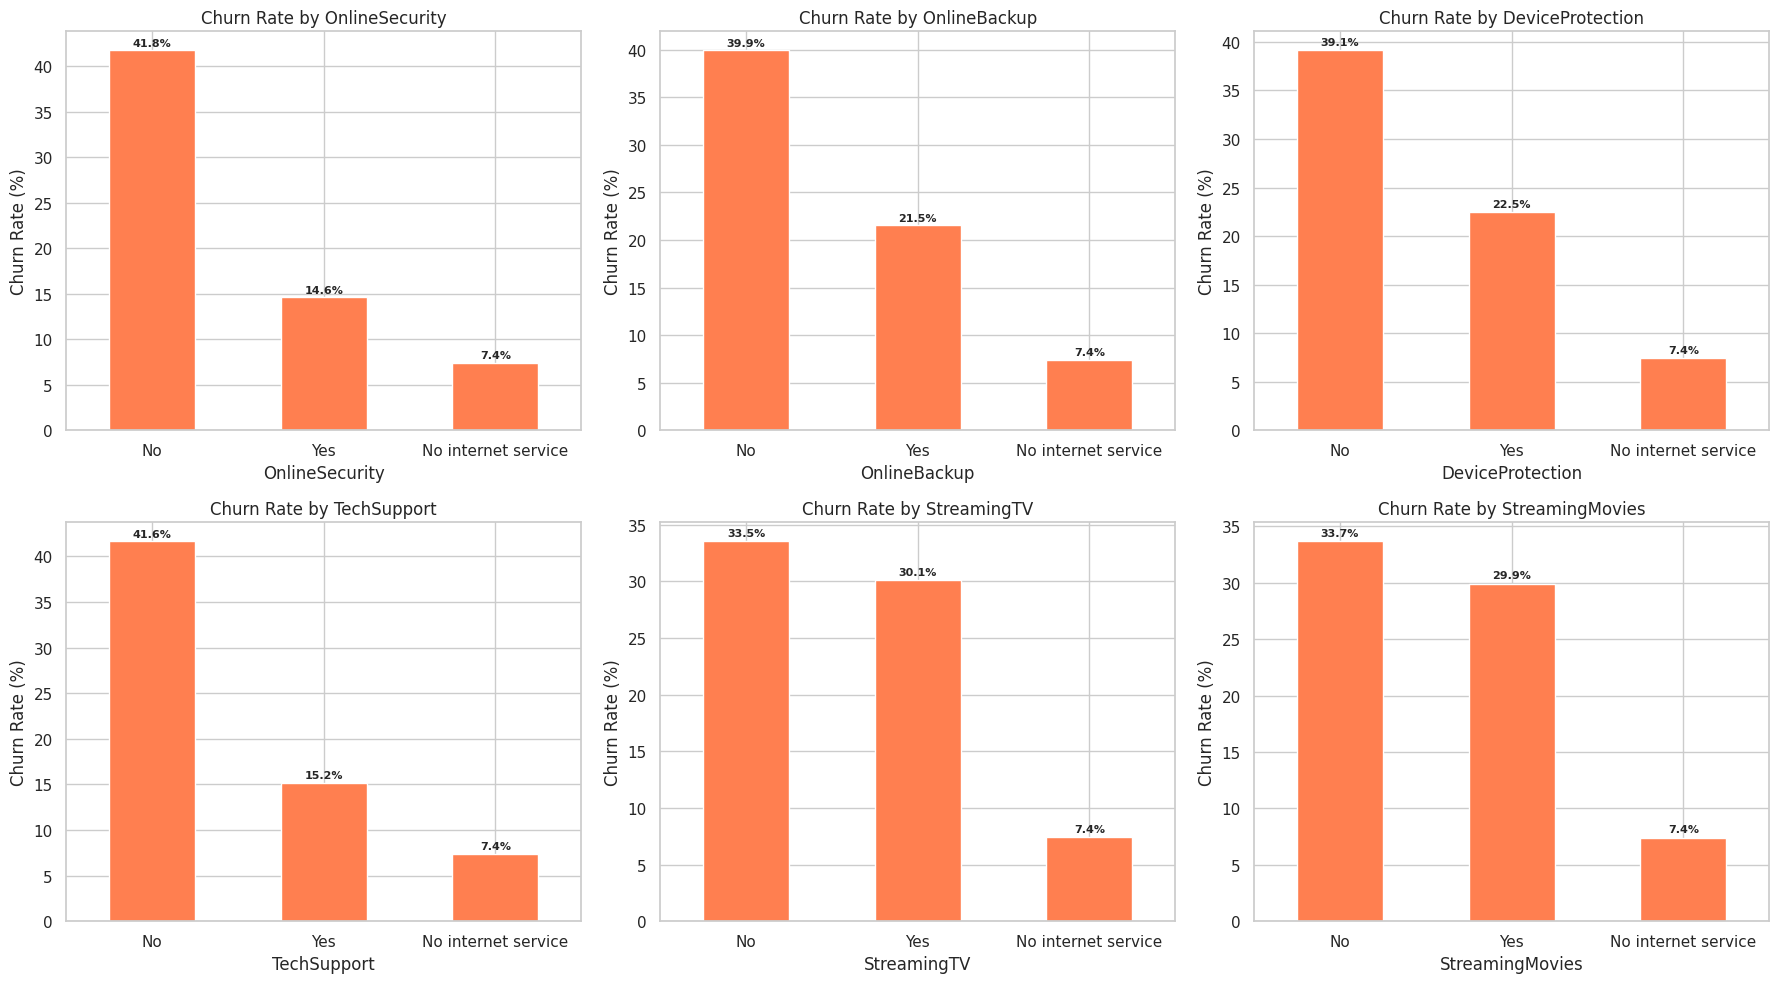

In [32]:
# Value-Added Services: churn rate by OnlineSecurity, OnlineBackup, DeviceProtection
# TechSupport, StreamingTV, StreamingMovies
value_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
              "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(2, 3 , figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(value_cols):
    churn_rate = df.groupby(col)["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
    order = churn_rate.sort_values(ascending=False).index
    churn_rate[order].plot(kind="bar", ax=axes[i], color="coral")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=0)
    for j, v in enumerate(churn_rate[order]):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.show()

**Observations:**

All six value-added service columns share the same 3-level structure: `"Yes"`, `"No"`, `"No internet service"`. The `"No internet service""` category consistently shows the lowest churn rate (~7%) — these are customers without internet at all, a distinct low-rist segment already identified.

Comparing `"Yes"` vs `"No"` within each service:

- **OnlineSecurity:** No = 41.8% churn vs Yes = 14.6% — huge gap. Lack of security dramatically increases risk.
- **OnlineBackup:** No = 39.9% vs Yes = 21/2% — missing backup doubles churn risk.
- **DeviceProtection:** No = 31.9% vs Yes = 22.2% — similar pattern 
- **TechSupport:** No = 41.8% churn vs Yes = 14.6% — huge gap. Lack of tech support is a major churn signal 
- **StreamingTV:** No = 33.5% vs Yes = 29.7% — small gap. Streaming has minimal impact 
- **StreamingMovies:** No = 33.7% vs Yes = 29.8% — simiraly weak signal 

**Pattern:** **Protective services** (security, backup, device protection, tech support) strongly correlate with retention. **Entertainment services** (streaming) barely move the needle. 

**Note:** These features may be correlated with each other and with `InternetService`. We'll investigate further in Section 8.

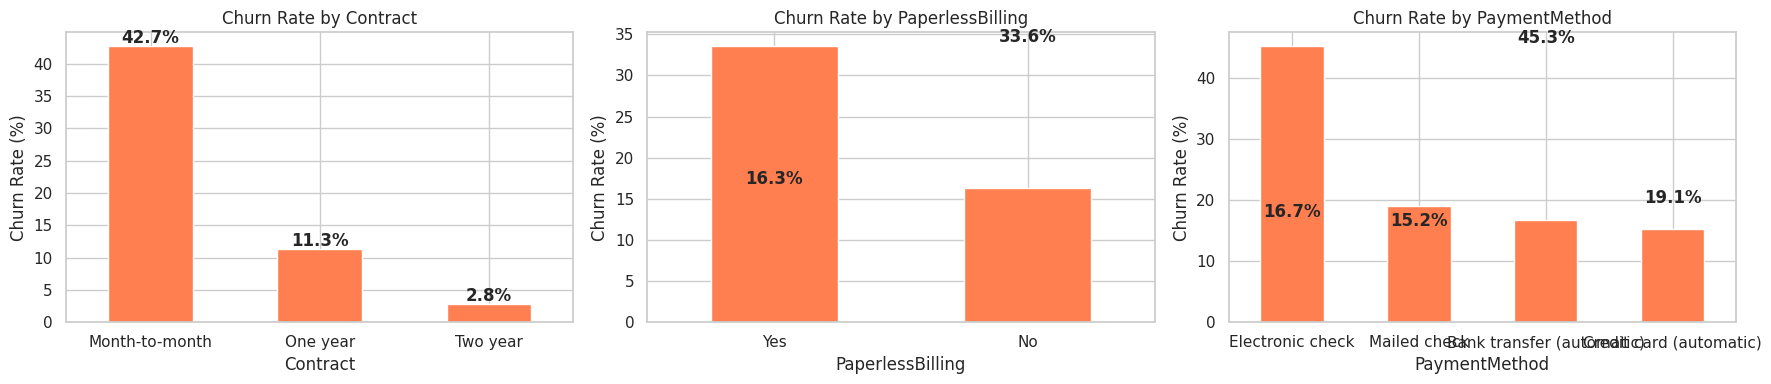

In [35]:
# Billing & Contract: Churn rate by Contract, PaperlessBilling, PaymentMethod
billing_cols = ["Contract", "PaperlessBilling", "PaymentMethod"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(billing_cols):
    churn_rate = df.groupby(col)["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
    churn_rate.sort_values(ascending=False).plot(kind="bar", ax=axes[i], color="coral")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=0)
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observations:**

- **Contract:** Already analyzed in Section 5. Month-to-month = 42.7%, One year = 11.3%, Two year = 2.8%. Dominant predictor.

- **PaperlessBilling:** Customers with paperles billing churn at 33.6% vs 16.9% for paper billing. Nearly double. Paperless billing may indicate less engagement with physical statements or a preference for digital-only interaction — possibly a proxy for lower switching friction.

- **PaymentMethod:** Electronic check users churn at 45.3% — far higher than any other method (mailed check 19.1% , bank transfer 16.7%, credit card 15.2%). Electronic check is a strong churn indicator. May correlate with lower income, lower commitment, or higher paymeny friction (manual recurring payments vs auto-draft).

Billing features carry strong signal. `PaymentMethod` (electronic check) and `PaperlessBilling` (yes) are significant churn risk factors alongside `Contract`.

## 8. Feature Interactions & Correlations 

We now examine how features relate to each other, not just to churn. 

**Objectives:**

1. Detect multicollinearity among numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`)
2. Identify categorical feature associations (e.g., `InternetService` driving the "No internet service" columns)
3. Spot interaction effects — where two features together predict churn better than either alone 
4. Confirm or refute hypothesis from earlier sections 

We'll use correlation matrics, cross-tabulations, and grouped churn rates for interactions.

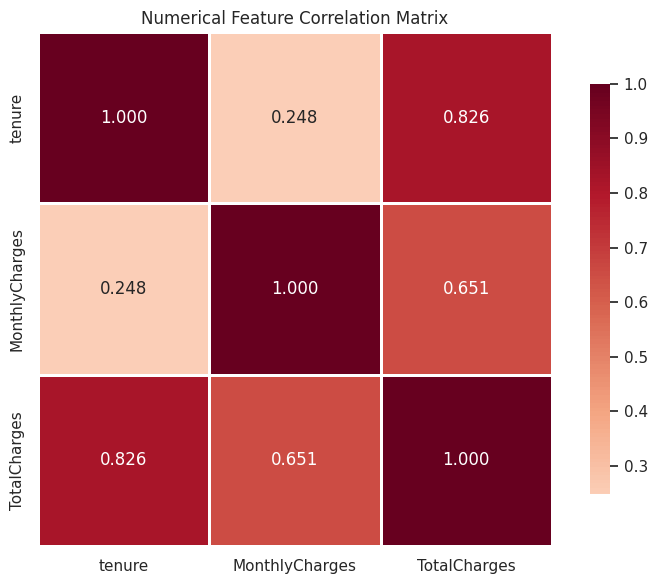

In [38]:
# Numerical correlation matrix
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0, square=True,
            linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations:**

- **tenure ↔ TotalCharges: r = 0.83** — strong correlation. TotalCharges is largely tenure x MonthlyCharges. This is expected and confirms Section 6 suspicios.
- **tenure ↔ MonthlyCharges: r = 0.25** — weak positive correlation. Longer-tenure customers tend to have slightly higher monthly charges, but the relationship is mild.
- **MonthlyCharges ↔ TotalCharges: r = 0.65** — moderate correlation. 

**Implication for modeling:**
- `TotalCharges` is highly collinear with `tenure` (0.83). Tree-based models (XGBoost) are robust to multcollinearity, but including both adds little marginal value.
- If we were using a linear model (Logistic Regression baseline), we'd likely drop `TotalCharges` to avoid instability.
- For XGBoost we can keep both and let feature importance sort it out. This will be verified during training.

In [39]:
# Categorical association: InternetService vs value-added service
# columns. If InternetService == "No", all value-added columns
# should be "No internet service"
value_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]

for col in value_cols:
    # Build cross-tab of InternetService vs this column
    cross = pd.crosstab(df["InternetService"], df[col])
    print(f"--- {col} ---")
    display(cross)
    print()

--- OnlineSecurity ---


OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1241,0,1180
Fiber optic,2257,0,839
No,0,1526,0



--- OnlineBackup ---


OnlineBackup,No,No internet service,Yes
InternetService,,,
DSL,1335,0,1086
Fiber optic,1753,0,1343
No,0,1526,0



--- DeviceProtection ---


...

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,1243,0,1178
Fiber optic,2230,0,866
No,0,1526,0



--- StreamingTV ---


StreamingTV,No,No internet service,Yes
InternetService,,,
DSL,1464,0,957
Fiber optic,1346,0,1750
No,0,1526,0



--- StreamingMovies ---


StreamingMovies,No,No internet service,Yes
InternetService,,,
DSL,1440,0,981
Fiber optic,1345,0,1751
No,0,1526,0


**Observations:**

The cross-tabs confirm the structural dependency exactly:
- When `InternetService == "No"`, every value-added column shows `"No internet service"` — all 1,526 rows.
- Zero exceptions. This is a determinstic rule, not correlation.

**Preprocessing decision:**
- These columns contain redundant information. We have two clean options:
  1. **Collapse:** Convert all `"No internet service"` values to `"No"` — since having no internet means you *de facto* don't have online security, backup, etc. This loses the distinction between "I have internet but opted out" vs "I don't have internet."
  2. **Keep as-is:** Let the model learn the interaction. Tree models will split on `InternetService` first, then use value-added features only when applicable.
- **We'll choose Option 1 (Collapse to "No")** for simplicity and fewer redundant one-hot columns. The model can still differentiate via the `InternetService` feature itself.
- Alternative: create an interaction feature (`has_internet x service_opted_in`). v2 enhancement.

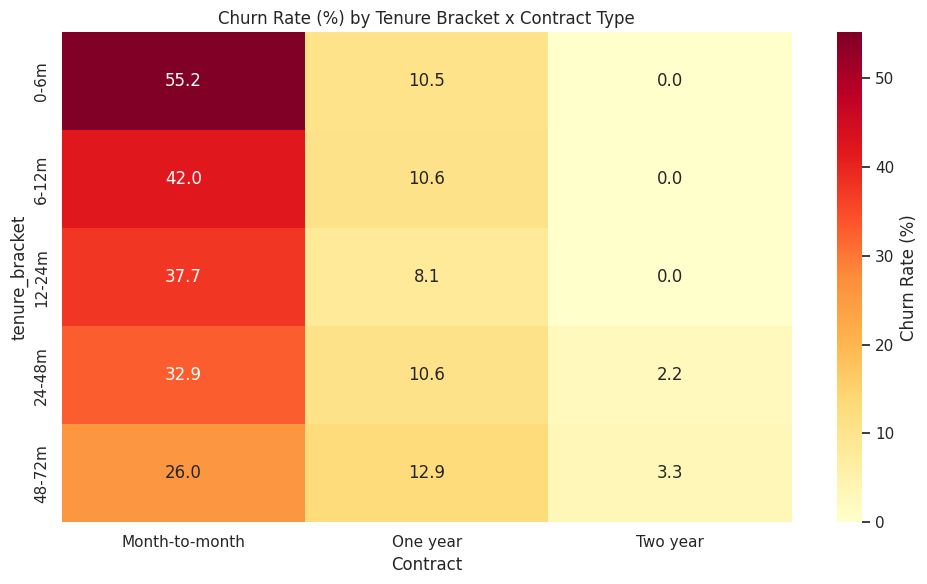

In [42]:
# Interaction: Tenure bracket x contract type
# Churn rate heatmap
df["tenure_bracket"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 73],
    labels=["0-6m", "6-12m", "12-24m", "24-48m", "48-72m"]
)
df["Contract"] = pd.Categorical(df["Contract"], categories=["Month-to-month",
                                                            "One year", "Two year"], ordered=True)
interaction = df.pivot_table(
    index="tenure_bracket",
    columns="Contract",
    values="Churn",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(interaction, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "Churn Rate (%)"}, ax=ax)
ax.set_title("Churn Rate (%) by Tenure Bracket x Contract Type")
plt.tight_layout()
plt.show()

**Observations:**

This heatmap reveals a powerful interaction:

- **Two-year contract:** Near-zero churn across all tenure brackets (0.0-3.3%). Even the 48-72m bracket with two-year contracts show only 3.5% churn. These contract length itself suppresses churn almost entirely.
- **One-year contract:** Moderate churn (8.1-12.9%) across all tenure levels. Tenure has little effect within this group — the annual commitment stabilizes behavior.
- **Month-to-month contract:** High churn everywhere, with a clear tenure gradient:
  - 0-6m: **55.2%** — more than half leave 
  - 6-12m: **42.0%** — still extreme
  - 12-24m: **37.7%** — declining but severe 
  - 24-48m: **32.9%** — even long-tenure month-to-month customers churn at rates higher than any one-year or two-year segment.
  - 48-72m: **26.0%** — the lowest month-to-month rate, yet still 8x the two-year rate 

**Key insight:**
- Contract type dominates tenure. A 48-72m month-to-month customer (26.0%) is far riskier than a 0-6m two-year customer (0.0%).
- The combination `(tenure < 12m) + (Contrat == Month-to-month)` flags the highest-risk cohort at 42-55% churn.
- XGBoost should capture this interaction automaticaly through tree splits. An explicit interaction feature could boost the Logistic Regression Baseline.

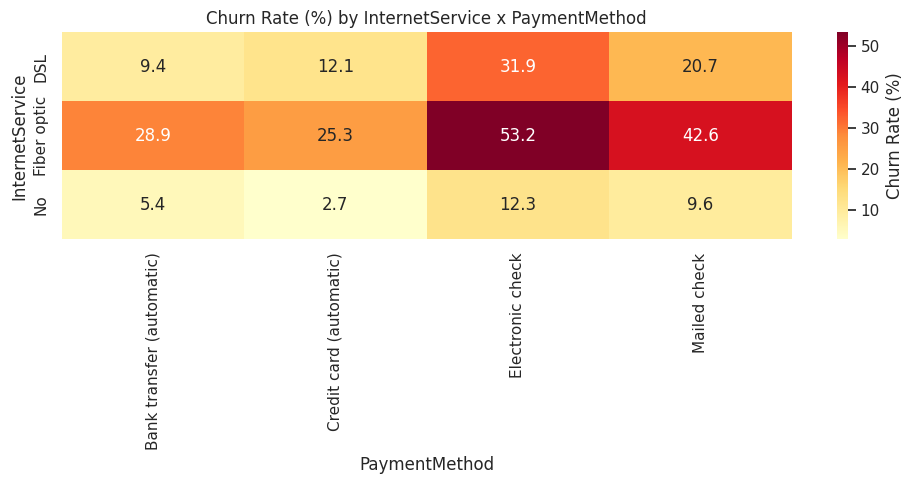

In [44]:
# Interaction: InternetService x PaymentMethod
interaction2 = df.pivot_table(
    index="InternetService",
    columns="PaymentMethod",
    values="Churn",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(interaction2, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "Churn Rate (%)"}, ax=ax)
ax.set_title("Churn Rate (%) by InternetService x PaymentMethod")
plt.tight_layout()
plt.show()

**Observations:**

This interaction reveals compounding risk factors:

- **Fiber optic + Electronic check: 53.2%** — the single highest-risk combination. More than half of these customers churn.
- **No internet + Credit Card (automatic): 2.7%** — the lowest-risk combination. Nearly guaranteed retention.
- The spread is enormous: from ~3% to 53% depending on the combination of these two features alone.

**Pattern:**
- Electronic check consistently worsens churn across all internet types. It's likely a proxy for lower-incode, less-stable customers, or higher payment friction.
- Automatic payment methods (bank transfer, credit card) are associated with much lower churn — they reduce involuntary churn (failed payments) and signal commitment.
- Fiber optic amplifies churn risk across all payment methods compared to DSL or No internet. 

This reinforces that `PaymentMethod` (specifically Electronic check) and `InternetService` (Fiber optic) are two of the strongest categorical predictors.

## 9. Data Quality Issues & Anomalie 

We now consolidate all data quality findings from Section 2-8 into a single checklist.
This serves as the input to the preprocessing and validation pipeline stages.

We'll also check for:
- Duplicate rows.
- Illogical value combinatios.
- Any remaining edge cases not yet surfaced.

In [45]:
# Check for duplicate rows (excluding customerID)
duplicate_mask = df.drop(columns="customerID").duplicated()
duplicate_count = duplicate_mask.sum()

print(f"Duplicate rows (excluding customerID): {duplicate_count}")

# Check for duplicate customerIDs
print(f"Duplicate customerID: {df["customerID"].duplicated().sum()}")

Duplicate rows (excluding customerID): 22
Duplicate customerID: 0


**Observations:**

- 22 rows are full duplicates (all features identical except `customerID`). This is a minor issue — possibly data entry errors or genuine customers with identical profiles.
- 0 duplicate `customerID` values — each customer is unique
- **Decision:** Drop the 22 duplicates during preprocessing. They represent < 0.3% of the dataset and won't affect model training meaningfully, but keeping them is technically incorrect if they are true duplicates.

In [47]:
# Check for illogical combinations: tenure = 0 but TotalCharges > 0
illogical = df[(df['tenure'] == 0) & (df['TotalCharges'] > 0)]
print(f"tenure=0 but TotalCharges>0: {len(illogical)} rows")

# Check: tenure>0 but TotalCharges == 0
illogical2 = df[(df["tenure"] > 0) & (df['TotalCharges'] == 0)]
print(f"tenure>0 but TotalCharges=0: {len(illogical2)} rows")

# Check: MonthlyCharges == 0
print(f"MonthlyCharges=0: {(df["MonthlyCharges"] == 0).sum()} rows")

# Check: tenure negative
print(f"tenure<0:  {(df["tenure"] < 0).sum()} rows")

# Check: MonthlyCharges negative
print(f"MonthlyCharges<0: {(df['MonthlyCharges'] < 0).sum()} rows")

tenure=0 but TotalCharges>0: 0 rows
tenure>0 but TotalCharges=0: 0 rows
MonthlyCharges=0: 0 rows
tenure<0:  0 rows
MonthlyCharges<0: 0 rows


**Observations:**

- No illogical combinations found. The dataset is internally consistent:
  - `tenure = 0` always corresponds to `TotalCharges = 0` (new customers, no billing history)
  - `tenure > 0` always has `TotalCharges > 0`.
  - No zero or negative values in `MonthlyCharges` or `tenure`
- Our `TotalCharges` fill logic (blanks → 0, Cell 30) is validated: it produced no contradictions.

In [ ]:
# Check SeniorCitizin is only 0 or 1
print("SeniorCitizen value counts:")
display(df["SeniorCitizen"].value_counts())

# Checll all Yes/No binary columns for unexpected values
binary_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_yes_no:
    vals = df[col].unique()
    unexpected = [v for v in vals if v not in ["Yes", "No"]]
    if unexpected:
        print(f"Warning: {col} has unexpected values: {unexpected}")
    else:
        print(f"{col}: OK {vals.tolist()}")


SeniorCitizen value counts:


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner: OK ['Yes', 'No']
Dependents: OK ['No', 'Yes']
PhoneService: OK ['No', 'Yes']
PaperlessBilling: OK ['Yes', 'No']
Churn: OK ['No', 'Yes']


**Observations:**

- `SeniorCitizen` is correctly encoded as 0/1 (integer). 1,142 seniors (16.2%), 5901 non-seniors. This mathes the spec.
- All binary Yes/No columns contain only expected values `["Yes", "No"]` — no typos, no case inconsistencies.
- `Churn` distribution confirmed: 1,869 Yes, 5,174 No.

Dataset is clean and internally consistent. Encoding mismatches (`SeniorCitizen` as 0/1 vs everything else as Yes/No) will be standardized in preprocessing.

## 10. Conclusions & Next Steps

### 10.1 Data Quality Summary

| Issue | Severity | Action |
|-------|----------|--------|
| `TotalCharges` stored as object (blanks) | High | Convert to numeric, fill blanks with 0 (tenure=0 customers) |
| 22 duplicate rows (excluding `customerID`) | Low | Drop during preprocessing |
| `"No internet service"` / `"No phone service"` as separate categories | Medium | Collapse to `"No"` for modeling simplicity |
| Inconsistent binary encoding (`SeniorCitizen` 0/1 vs Yes/No) | Low | Standardize all binaries to 0/1 |
| `customerID` is an identifier, not a feature | — | Drop before training |

**Overall:** The dataset is remarkably clean — no nulls in the traditional sense, no outliers by IQR, no illogical combinations. Most preprocessing work will be encoding and standardization, not repair.

### 10.2 Predictive Signal Summary

| Feature | Signal Strength | Direction |
|---------|----------------|-----------|
| **Contract** | 🔴 Very Strong | Month-to-month → high churn; Two-year → near zero |
| **Tenure** | 🔴 Very Strong | Low tenure → high churn; monotonic decline |
| **InternetService** | 🔴 Very Strong | Fiber optic → high churn; No internet → very low |
| **PaymentMethod** | 🟠 Strong | Electronic check → high churn; auto-pay → low |
| **TechSupport** | 🟠 Strong | No tech support → high churn |
| **OnlineSecurity** | 🟠 Strong | No online security → high churn |
| **PaperlessBilling** | 🟡 Moderate | Paperless → higher churn |
| **SeniorCitizen** | 🟡 Moderate | Senior → higher churn |
| **Dependents** | 🟡 Moderate | No dependents → higher churn |
| **Partner** | 🟡 Moderate | No partner → higher churn |
| **TotalCharges** | 🟡 Moderate | Low → higher churn (tenure proxy) |
| **MonthlyCharges** | 🟢 Weak-Moderate | Higher → higher churn |
| **StreamingTV/StreamingMovies** | 🟢 Weak | Minimal difference |
| **gender** | ⬜ None | Near-identical rates |

### 10.3 Key Interactions

- **Tenure × Contract:** The combination of low tenure + month-to-month contract creates the highest-risk cohort (55% churn).
- **InternetService × PaymentMethod:** Fiber optic + Electronic check = 53% churn. Automatic payment methods reduce risk across all internet types.
- **Contract dominates tenure:** A high-tenure month-to-month customer is riskier than a low-tenure two-year contract customer.

### 10.4 Next Steps

1. **Notebook 02 — Baseline Model:** Train a simple Logistic Regression to establish a performance floor.
2. **Notebook 03 — Model Comparison:** Benchmark XGBoost vs LightGBM vs Baseline on validation metrics.
3. **Notebook 04 — SHAP Analysis:** Deep dive into feature importance and explanation.
4. **Pipeline implementation:** Codify preprocessing, training, and evaluation based on findings from these notebooks.